#  **Introduction to Machine Learning Phase 3 (CNN-based)**

Thông tin các thành viên:

| Mã sinh viên | Họ và Tên        |
|--------------|------------------|
| 22120071     | Phan Bá Đức      |
| 22120078     | Nguyễn Bá Duy    |
| 22120182     | Đặng Duy Lân     |



**Tìm hiểu về dữ liệu**

| Thuộc tính                     | Mô tả                                                                                  | Kích thước                    |
|----------------------------------|---------------------------------------------------------------------------------------|------------------------------|
| **vid_id**                       | YouTube video ID liên quan đến mẫu dữ liệu này                                       | (n_sample, 1)               |
| **start_time_seconds_youtube_clip** | Thời điểm bắt đầu của đoạn audio trong video YouTube (tính bằng giây)               |(n_sample, 1)            |
| **end_time_seconds_youtube_clip**   | Thời điểm kết thúc của đoạn audio trong video YouTube (tính bằng giây)              |  (n_sample, 1)            |
| **audio_embedding**              | Đặc trưng âm thanh theo từng frame, giảm chiều xuống còn 128 chiều bằng VGGish       | (n_sample,frame, 128)              |
| **is_turkey**                   | Nhãn mục tiêu: 1 nếu đoạn audio chứa tiếng gà tây, 0 nếu không, dựa trên ontology AudioSet | Số thực (n_sample, 1)              |



## **Import thư viện và đọc và phân tích dữ liệu**

In [ ]:
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, roc_curve
import numpy as np
from itertools import product
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, KFold
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras import layers, models
import os

In [ ]:
# Tải dữ liệu
# with open('data/train.json', 'r') as f:
with open('train.json', 'r') as f:
    data = json.load(f)

In [ ]:
# Chuyển qua dataframe
df = pd.DataFrame(data)

print("Số lượng mẫu:", len(df))
print('Kiểm tra missing values:', df.isnull().values.any())

Số lượng mẫu: 1195
Kiểm tra missing values: False


In [ ]:
def extract_info(data):
    '''
    Hàm này trích xuất thông tin từ dữ liệu JSON

    param
        data: Dữ liệu JSON
    return: Một dictionary chứa thông tin về video

    vid_id: ID của video
    is_turkey: Nhãn (1/0)
    frame: Số lượng frame trong mẫu dữ liệu
    dimension: Kích thước của các embedding âm thanh
    duration: Thời gian của video (tính bằng giây) = end_time_seconds_youtube_clip - start_time_seconds_youtube_clip
    '''
    audio_embeddings = data['audio_embedding']

    return {
        'vid_id': data['vid_id'],
        'is_turkey': data['is_turkey'],
        'frame': len(audio_embeddings),
        'dimension': set(len(embedding) for embedding in audio_embeddings),
        'duration': data['end_time_seconds_youtube_clip'] - data['start_time_seconds_youtube_clip']
    }

df = pd.DataFrame([extract_info(item) for item in data])

In [ ]:
print('Số lượng mẫu trong dữ liệu là: ', len(df))
print('Số lượng video duy nhất trong dữ liệu là: ',df['vid_id'].nunique())
print('Thông tin mô tả dữ liệu:')
df.describe().T

Số lượng mẫu trong dữ liệu là:  1195
Số lượng video duy nhất trong dữ liệu là:  1195
Thông tin mô tả dữ liệu:


,count,mean,std,min,25%,50%,75%,max
is_turkey,1195.0,0.410879,0.492199,0.0,0.0,0.0,1.0,1.0
frame,1195.0,9.870293,0.730351,2.0,10.0,10.0,10.0,10.0
duration,1195.0,9.928033,0.621913,2.0,10.0,10.0,10.0,10.0


In [ ]:
print('Kiểm tra các frame có cùng số lượng dimension hay không:')
set().union(*df['dimension'])

Kiểm tra các frame có cùng số lượng dimension hay không:


{128}

=> Các frame chỉ có một số lượng dimension duy nhất, đó là 128.

In [ ]:
print('Thống kê số lượng nhãn is_turkey:')
df['is_turkey'].value_counts()

Thống kê số lượng nhãn is_turkey:


,count
is_turkey,
0,704
1,491


Có 704 mẫu thuộc lớp 0 và 491 mẫu thuộc lớp 1 cho thấy dữ liệu bị mất căn bằng ở mức trung bình

## **Quy Trình Xử Lý Dữ Liệu**

1. Tải dữ liệu:
  - Đọc file`train.json` sử dụng thư viện json.
  - Tạo đối tượng `AudioDataset` để quản lý dữ liệu.


2. Chuẩn hóa và padding:
  - Chuẩn hóa `audio_embedding` bằng cách chia cho 255 để đưa giá trị về [0, 1].
  - Thêm Pad các chuỗi đặc trưng bằng 0 để đồng bộ độ dài (dựa trên chuỗi dài nhất), đảm bảo đầu vào nhất quán cho mô hình CNN.

3. Chia dữ liệu:
  - Sử dụng `train_test_split` với `stratify` để chia dữ liệu thành tập train (80%) và test (20%), giữ tỷ lệ lớp (0 và 1) ở cả hai tập.

4. Xử lý mất cân bằng:
  - Áp dụng SMOTE để tạo mẫu giả cho lớp thiểu số (lớp 1) trong tập train, đưa tỷ lệ lớp về ~1:1.
  - Tính class weights để ưu tiên lớp thiểu số trong hàm loss.

---
### Kỹ Thuật Sử Dụng

1. SMOTE (Synthetic Minority Over-sampling Technique):
  - Tác dụng: Cân bằng dữ liệu bằng cách tạo mẫu giả cho lớp thiểu số, giúp mô hình học tốt hơn trên lớp `is_turkey=1`.
  - Cách thực hiện: Reshape dữ liệu train thành 2D, áp dụng SMOTE, rồi reshape lại thành 3D.

2. Class Weights:
  - Tác dụng: Tăng trọng số cho lớp thiểu số trong hàm loss, giảm thiên vị đối với lớp chiếm ưu thế.
  - Cách thực hiện: Tính trọng số dựa trên phân bố lớp sau SMOTE.

3. Stratified Splitting:
  - Tác dụng: Đảm bảo tỷ lệ lớp tương tự giữa tập train và test.
  - Cách thực hiện: Sử dụng `stratify` trong `train_test_split`.

4. Threshold Optimization:
  - Tác dụng: Tối ưu hóa ngưỡng dự đoán để tối đa hóa F1-score.
  - Cách thực hiện: Thử các ngưỡng từ 0.1 đến 0.9 trong mỗi fold.

5. Regularization:
  - Tác dụng: Giảm overfitting, cải thiện khả năng khái quát hóa.
  - Cách thực hiện: Dropout (0.3 sau Conv1D, 0.5 sau Dense) và L2 regularization (hệ số 0.02).

6. Early Stopping:
  - Tác dụng: Ngăn huấn luyện quá mức.
  - Cách thực hiện: Dừng nếu `val_loss` không cải thiện sau 3 epochs.

7. 5-Fold Cross-Validation:
  - Tác dụng: Đánh giá hiệu suất mô hình ổn định.
  - Cách thực hiện: Chia tập train resampled thành 5 fold.
---

### Mô Hình CNN

Mô hình được xây dựng bằng lớp `TurkeyCNN`:

* Kiến trúc
  - 3 tầng `Conv1D` (64, 128, 256 bộ lọc, kernel size=3, padding='same').
  - `MaxPooling1D` (pool size=2) sau mỗi Conv1D.
  - `Dropout(0.3)` sau Conv1D thứ ba.
  - `GlobalMaxPooling1D` để tổng hợp đặc trưng.
  - `Dense(128, relu)` với L2 regularization (0.02).
  - `Dropout(0.5)` trước tầng đầu ra.
  - `Dense(1, sigmoid)` để dự đoán xác suất.

* Huấn luyện:
  - Optimizer: Adam.
  - Loss: Binary cross-entropy.
  - Metrics: Accuracy.
  - Epochs: Tối đa 20, với early stopping.
  - Batch size: 32.

* Lưu và tải mô hình:
  - Lưu bằng`model.save('best_model.keras')`.
  - Tải bằng `tf.keras.models.load_model` với `custom_objects={'TurkeyCNN': TurkeyCNN}`.

In [ ]:
# Lớp AudioDataset để xử lý dữ liệu âm thanh
class AudioDataset(Dataset):
    """
    Dataset class để tải và xử lý dữ liệu âm thanh từ file JSON.
    Tích hợp padding để đồng bộ độ dài chuỗi đặc trưng âm thanh.

    Args:
        data (list): Danh sách các mẫu dữ liệu từ file JSON.
        max_length (int, optional): Độ dài tối đa của chuỗi. Nếu None, tự tính.
        is_test (bool): Nếu True, không tải nhãn (cho dữ liệu test).
    """
    def __init__(self, data, max_length=None, is_test=False):
        self.is_test = is_test
        self.embeddings = []  # Lưu đặc trưng âm thanh (audio embeddings)
        self.vid_ids = []     # Lưu ID video
        self.labels = []      # Lưu nhãn (is_turkey)

        # Tìm độ dài tối đa của chuỗi nếu không được chỉ định
        if max_length is None:
            max_length = max(len(sample['audio_embedding']) for sample in data)

        # Xử lý từng mẫu dữ liệu
        for sample in data:
            seq = np.array(sample['audio_embedding'], dtype=np.float32) / 255.0  # Chuẩn hóa giá trị về [0, 1]
            # Pad chuỗi để đồng bộ độ dài
            padded_seq = np.pad(seq, ((0, max_length - len(seq)), (0, 0)), mode='constant', constant_values=0)
            self.embeddings.append(padded_seq)
            self.vid_ids.append(sample['vid_id'])
            if not is_test:
                self.labels.append(sample['is_turkey'])

    def __len__(self):
        """Trả về số lượng mẫu trong dataset."""
        return len(self.embeddings)

    def __getitem__(self, idx):
        """
        Lấy mẫu tại chỉ số idx.

        Returns:
            tuple: (embedding, label, vid_id) nếu không phải test, (embedding, vid_id) nếu là test.
        """
        embedding = torch.tensor(self.embeddings[idx], dtype=torch.float32)
        vid_id = self.vid_ids[idx]
        if self.is_test:
            return embedding, vid_id
        return embedding, torch.tensor(self.labels[idx], dtype=torch.float32), vid_id

# Lớp mô hình CNN để phân loại âm thanh
class TurkeyCNN(models.Model):
    """
    Mô hình CNN để phân loại âm thanh gà tây (is_turkey).
    Bao gồm 3 tầng Conv1D, dropout, và các tầng Dense.

    Args:
        **kwargs: Các tham số bổ sung cho lớp Model (trainable, dtype, v.v.).
    """
    def __init__(self, **kwargs):
        super(TurkeyCNN, self).__init__(**kwargs)
        # Tầng Conv1D đầu tiên
        self.conv1 = layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')
        self.pool1 = layers.MaxPooling1D(pool_size=2)
        # Tầng Conv1D thứ hai
        self.conv2 = layers.Conv1D(filters=128, kernel_size=3, padding='same', activation='relu')
        self.pool2 = layers.MaxPooling1D(pool_size=2)
        # Tầng Conv1D thứ ba
        self.conv3 = layers.Conv1D(filters=256, kernel_size=3, padding='same', activation='relu')
        self.dropout_conv = layers.Dropout(0.3)  # Dropout để giảm overfitting
        # Tầng tổng hợp đặc trưng
        self.global_pool = layers.GlobalMaxPooling1D()
        # Tầng Dense với regularization
        self.dense1 = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.02))
        self.dropout = layers.Dropout(0.5)  # Dropout cho tầng Dense
        # Tầng đầu ra
        self.dense2 = layers.Dense(1, activation='sigmoid')

    def call(self, inputs):
        """
        Xử lý dữ liệu đầu vào qua các tầng của mô hình.

        Args:
            inputs: Tensor đầu vào (batch_size, sequence_length, 128).

        Returns:
            Tensor đầu ra (batch_size, 1) với xác suất is_turkey.
        """
        x = self.conv1(inputs)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x = self.dropout_conv(x)
        x = self.global_pool(x)
        x = self.dense1(x)
        x = self.dropout(x)
        return self.dense2(x)

    def get_config(self):
        """Trả về cấu hình của mô hình để lưu trữ."""
        config = super(TurkeyCNN, self).get_config()
        return config

    @classmethod
    def from_config(cls, config):
        """Tạo mô hình từ cấu hình."""
        return cls(**config)

In [ ]:
# Chuẩn bị dữ liệu cho TensorFlow
def prepare_data(dataset, is_test=False):
    """
    Chuyển dataset thành mảng numpy cho TensorFlow.

    Args:
        dataset: Dataset object (train hoặc test).

    Returns:
        tuple: (X, y) với X là đặc trưng, y là nhãn.
    """
    X, y, vid_id = [], [], []
    for i in range(len(dataset)):
      if not is_test:
        embedding, label, _ = dataset[i]
        X.append(embedding.numpy())
        y.append(label.numpy())
      else:
        embedding, vid_id_ = dataset[i]
        X.append(embedding.numpy())
        vid_id.append(vid_id_)
    if not is_test:
      return np.array(X), np.array(y)
    else:
      return np.array(X), vid_id

In [ ]:
# Load dataset từ file JSON
with open('train.json', 'r') as f:
    data = json.load(f)

# Tạo AudioDataset
dataset = AudioDataset(data)

# Chia dataset với stratified split để giữ tỷ lệ lớp
labels = [dataset[i][1].numpy() for i in range(len(dataset))]
train_idx, test_idx = train_test_split(np.arange(len(dataset)), test_size=0.2, random_state=71, stratify=labels)
train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)

X_train, y_train = prepare_data(train_dataset)
X_test, y_test = prepare_data(test_dataset)

# Kiểm tra phân bố lớp
print("Kiểm tra phân bố lớp trên 2 tập train và test")
print("Train class distribution:", np.bincount(y_train.astype(int)))
print("Test class distribution:", np.bincount(y_test.astype(int)))

# Áp dụng SMOTE để cân bằng lớp trong tập train
smote = SMOTE(random_state=71)
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)  # Reshape cho SMOTE
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_reshaped, y_train)
X_train_resampled = X_train_resampled.reshape(-1, X_train.shape[1], X_train.shape[2])  # Reshape lại

# Tính class weights để xử lý mất cân bằng
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_resampled), y=y_train_resampled)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

Kiểm tra phân bố lớp trên 2 tập train và test
Train class distribution: [563 393]
Test class distribution: [141  98]


In [ ]:
# Áp dụng 5-Fold Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_f1_scores = []
fold_accuracies = []
fold_training_times = []  # Lưu thời gian huấn luyện mỗi fold
fold_model_sizes = []    # Lưu kích thước mô hình mỗi fold
best_f1_score = 0.0
best_threshold = 0.5
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

for fold, (train_fold_idx, val_fold_idx) in enumerate(kfold.split(X_train_resampled)):
    print(f"Fold {fold+1}")

    # Lấy dữ liệu fold
    X_fold_train = X_train_resampled[train_fold_idx]
    y_fold_train = y_train_resampled[train_fold_idx]
    X_fold_val = X_train_resampled[val_fold_idx]
    y_fold_val = y_train_resampled[val_fold_idx]

    # Xây dựng và huấn luyện mô hình
    model = TurkeyCNN()
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    start_time = time.time()
    model.fit(X_fold_train, y_fold_train, epochs=20, batch_size=32, validation_data=(X_fold_val, y_fold_val),
              callbacks=[early_stopping], class_weight=class_weight_dict, verbose=1)
    end_time = time.time()
    training_time = end_time - start_time
    fold_training_times.append(training_time)
    print(f"Fold {fold+1} Training time: {training_time:.2f} seconds")

    # Lưu mô hình tạm thời để đo kích thước
    model_file = f"fold_{fold+1}_model.keras"
    model.save(model_file)
    # Đo kích thước file mô hình
    model_size_mb = os.path.getsize(model_file) / (1024 * 1024)  # Chuyển sang MB
    fold_model_sizes.append(model_size_mb)
    print(f"Fold {fold+1} Model size: {model_size_mb:.2f} MB")
    # Xóa file mô hình tạm thời
    if os.path.exists(model_file):
        os.remove(model_file)

    # Tìm ngưỡng tối ưu
    y_pred_proba = model.predict(X_fold_val)
    thresholds = np.arange(0.1, 0.9, 0.1)
    fold_best_f1 = 0
    fold_best_threshold = 0.5
    for threshold in thresholds:
        y_pred = (y_pred_proba > threshold).astype(int)
        f1 = f1_score(y_fold_val, y_pred)
        if f1 > fold_best_f1:
            fold_best_f1 = f1
            fold_best_threshold = threshold

    # Đánh giá với ngưỡng tốt nhất
    y_pred = (y_pred_proba > fold_best_threshold).astype(int)
    f1 = f1_score(y_fold_val, y_pred)
    acc = accuracy_score(y_fold_val, y_pred)
    fold_f1_scores.append(f1)
    fold_accuracies.append(acc)
    print(f"Fold {fold+1} F1-score: {f1:.4f}, Accuracy: {acc:.4f}, Best threshold: {fold_best_threshold:.2f}")
    print("*" * 50)

    # Lưu toàn bộ mô hình nếu có F1-score tốt nhất
    if f1 > best_f1_score:
        best_f1_score = f1
        best_threshold = fold_best_threshold
        model.save('best_model.keras')

# In kết quả cross-validation
print("\n")
print("-" * 50)
print(f"Best validation F1-score: {best_f1_score:.4f}, Best threshold: {best_threshold:.2f}")

Fold 1
Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7724 - loss: 3.4646 - val_accuracy: 0.9336 - val_loss: 1.9932
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9023 - loss: 1.8168 - val_accuracy: 0.9336 - val_loss: 1.1450
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9370 - loss: 1.0071 - val_accuracy: 0.9469 - val_loss: 0.6525
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9544 - loss: 0.5996 - val_accuracy: 0.9425 - val_loss: 0.4032
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9687 - loss: 0.3708 - val_accuracy: 0.9469 - val_loss: 0.3082
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9523 - loss: 0.2910 - val_accuracy: 0.9336 - val_loss: 0.2740
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9348 - loss: 0.2522 - val_accuracy: 0.9469 - val_loss: 0.1993
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9721 - loss: 0.1581 - val_accuracy: 0.9

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Fold 3 F1-score: 0.9557, Accuracy: 0.9600, Best threshold: 0.70
**************************************************
Fold 4
Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7445 - loss: 3.4121 - val_accuracy: 0.9111 - val_loss: 1.9930
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8825 - loss: 1.7940 - val_accuracy: 0.8844 - val_loss: 1.1949
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9412 - loss: 0.9409 - val_accuracy: 0.9378 - val_loss: 0.6167
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9332 - loss: 0.5617 - val_accuracy: 0.9289 - val_loss: 0.4429
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9355 - loss: 0.3865 - val_accuracy: 0.9511 - val_loss: 0.2865
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9661 - loss: 0.2234 - val_accuracy: 0.9467 - val_loss: 0.2510
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9781 - loss: 

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Fold 4 F1-score: 0.9667, Accuracy: 0.9644, Best threshold: 0.70
**************************************************
Fold 5
Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7968 - loss: 3.3681 - val_accuracy: 0.8800 - val_loss: 2.0533
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9411 - loss: 1.6688 - val_accuracy: 0.9556 - val_loss: 1.0422
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9481 - loss: 0.9045 - val_accuracy: 0.9600 - val_loss: 0.5965
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9603 - loss: 0.5104 - val_accuracy: 0.9644 - val_loss: 0.3720
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9458 - loss: 0.3515 - val_accuracy: 0.9600 - val_loss: 0.2725
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9615 - loss: 0.2216 - val_accuracy: 0.9644 - val_loss: 0.2182
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9721 - loss: 

In [ ]:
# In kết quả cross-validation
print(f"Mean cross-validation F1-score: {np.mean(fold_f1_scores):.4f}")
print(f"Mean cross-validation accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Mean training time per fold: {np.mean(fold_training_times):.2f} seconds")
print(f"Mean model size per fold: {np.mean(fold_model_sizes):.2f} MB")

Mean cross-validation F1-score: 0.9616
Mean cross-validation accuracy: 0.9618
Mean training time per fold: 11.16 seconds
Mean model size per fold: 2.11 MB


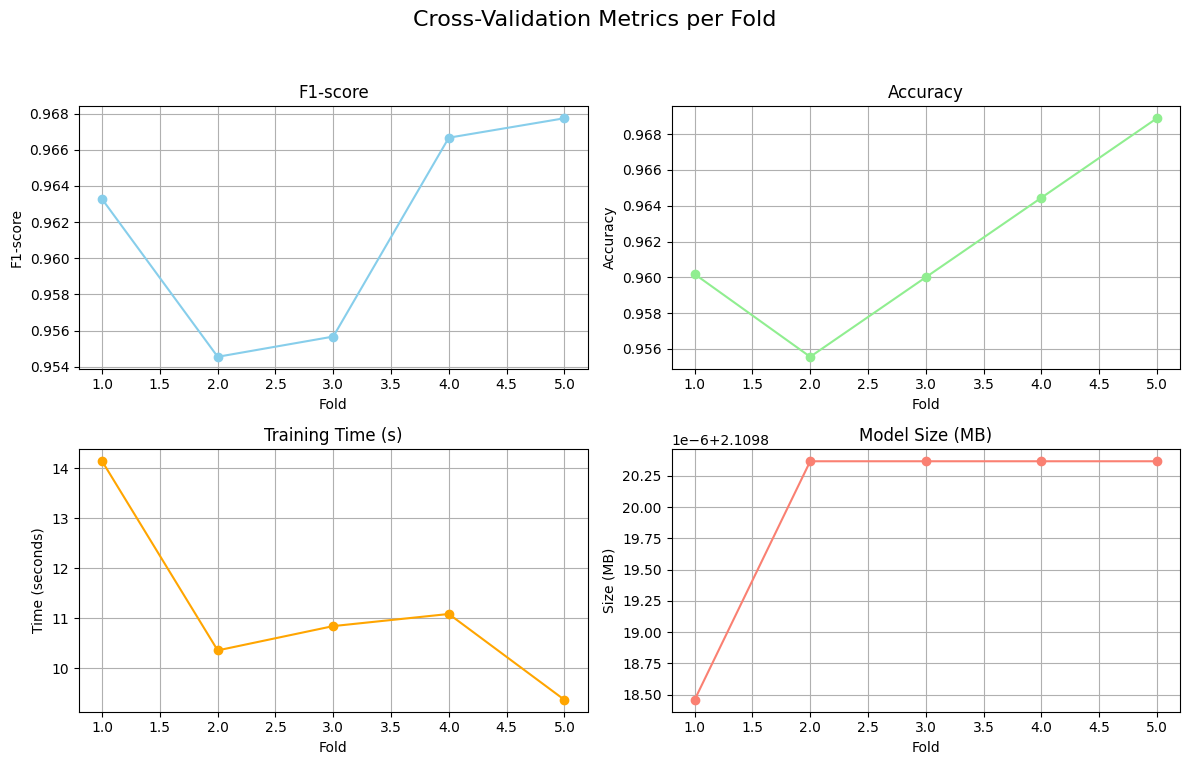

In [ ]:
import matplotlib.pyplot as plt

fold_indices = list(range(1, len(fold_f1_scores) + 1))

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Cross-Validation Metrics per Fold', fontsize=16)

# Biểu đồ F1-score
axs[0, 0].plot(fold_indices, fold_f1_scores, marker='o', color='skyblue')
axs[0, 0].set_title('F1-score')
axs[0, 0].set_xlabel('Fold')
axs[0, 0].set_ylabel('F1-score')
axs[0, 0].grid(True)

# Biểu đồ Accuracy
axs[0, 1].plot(fold_indices, fold_accuracies, marker='o', color='lightgreen')
axs[0, 1].set_title('Accuracy')
axs[0, 1].set_xlabel('Fold')
axs[0, 1].set_ylabel('Accuracy')
axs[0, 1].grid(True)

# Biểu đồ Training Time
axs[1, 0].plot(fold_indices, fold_training_times, marker='o', color='orange')
axs[1, 0].set_title('Training Time (s)')
axs[1, 0].set_xlabel('Fold')
axs[1, 0].set_ylabel('Time (seconds)')
axs[1, 0].grid(True)

# Biểu đồ Model Size
axs[1, 1].plot(fold_indices, fold_model_sizes, marker='o', color='salmon')
axs[1, 1].set_title('Model Size (MB)')
axs[1, 1].set_xlabel('Fold')
axs[1, 1].set_ylabel('Size (MB)')
axs[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Để không đè lên tiêu đề chính
plt.show()

  1. Hiệu suất dự đoán:
    - F1-score trung bình (0.9616) và accuracy trung bình (0.9618) cho thấy mô hình có hiệu suất rất cao và ổn định trên tập validation qua các fold. Các giá trị này gần nhau, phản ánh sự cân bằng tốt giữa độ chính xác và khả năng phát hiện lớp thiểu số (is_turkey=1), nhờ vào việc áp dụng SMOTE và class weights.

    - Biểu đồ F1-score và Accuracy theo fold cho thấy xu hướng tăng dần từ fold 1, fold 2 đến fold 5, với fold 5 đạt đỉnh (F1-score ~0.9677, Accuracy ~0.9689). Điều này có thể do sự phân bố dữ liệu sau SMOTE hoặc hiệu ứng early stopping trong các fold sau.



  2. Thời gian huấn luyện:
    - Thời gian trung bình mỗi fold là 11.16 giây, với dao động từ khoảng 10 giây (fold 5) đến 14 giây (fold 1), theo biểu đồ. Sự giảm dần thời gian có thể liên quan đến early stopping (dừng sớm sau 3 epoch không cải thiện), giúp mô hình hội tụ nhanh hơn ở các fold sau.


  3. Kích thước mô hình:
    - Kích thước trung bình của mô hình là 2.11 MB
    - Kích thước này rất nhỏ, phù hợp cho triển khai trên thiết bị có tài nguyên hạn chế (như edge devices)


  4. Độ ổn định:
    - Hiệu suất dao động nhẹ giữa các fold, cho thấy mô hình có độ ổn định tốt. - - Sự khác biệt có thể xuất phát từ cách chia dữ liệu stratified và ảnh hưởng của SMOTE.

    - Thời gian huấn luyện và kích thước mô hình cũng ổn định, với biến thiên nhỏ, phản ánh tính nhất quán trong quá trình huấn luyện.

## **Đánh giá mô hình trên tập test (20%)**

In [ ]:
# Tải lại mô hình tốt nhất và đánh giá trên tập test
final_model = tf.keras.models.load_model('best_model.keras', custom_objects={'TurkeyCNN': TurkeyCNN})
y_pred_test_proba = final_model.predict(X_test)
y_pred_test = (y_pred_test_proba > best_threshold).astype(int)

test_f1 = f1_score(y_test, y_pred_test)
test_acc = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_auc_roc = roc_auc_score(y_test, y_pred_test)  # Sử dụng xác suất để tính AUC-ROC

print(f"Test F1-score: {test_f1:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test precision: {test_precision:.4f}")
print(f"Test recall: {test_recall:.4f}")
print(f"Test AUC-ROC: {test_auc_roc:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Test F1-score: 0.9388
Test accuracy: 0.9498
Test precision: 0.9388
Test recall: 0.9388
Test AUC-ROC: 0.9481


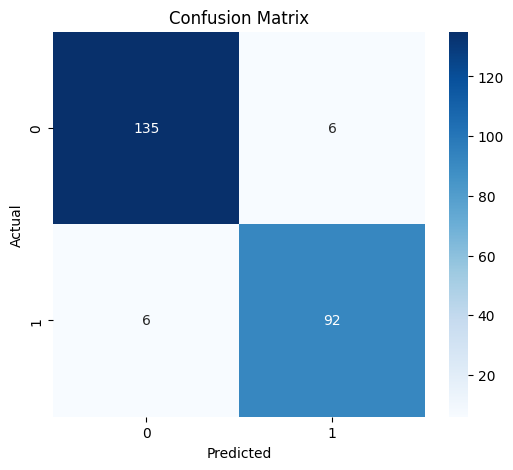

In [ ]:
# Tính confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Vẽ confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

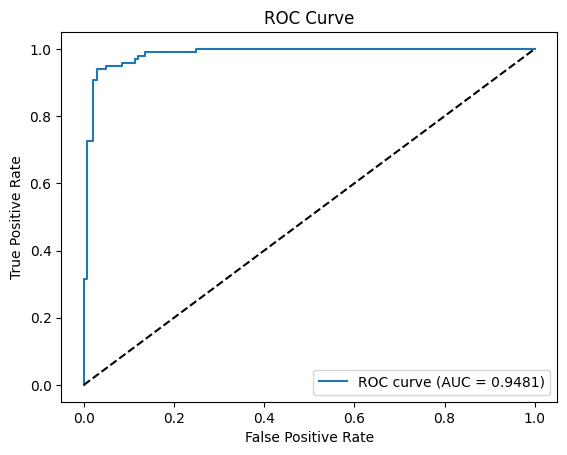

In [ ]:
# Tính toán FPR và TPR cho đường cong ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_test_proba)

# Vẽ đường cong ROC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {test_auc_roc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')  # Đường ngẫu nhiên
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

### Phân tích hiệu suất


1. Hiệu suất tổng quan:
  - Mô hình đạt accuracy 0.9498 khá cao
  - F1-score 0.9388 và AUC-ROC 0.9481 là các chỉ số rất tốt, phản ánh khả năng phân loại cân bằng giữa lớp is_turkey=0 và is_turkey=1.

2. Confusion Matrix:
  - True Negatives (135) và True Positives (92) chiếm phần lớn, cho thấy mô hình dự đoán chính xác trên cả hai lớp.
  - False Positives (6) và False Negatives (6) là số lượng lỗi nhỏ, tương ứng với tỷ lệ lỗi khoảng 2.5% (6/239), rất thấp.
  - Tỷ lệ FP và FN gần bằng nhau (6 và 6) cho thấy mô hình không thiên lệch rõ rệt về lớp nào, phù hợp với dữ liệu đã được cân bằng bằng SMOTE.

3. Điểm yếu tiềm ẩn:
  - Sai sót nhỏ trong phân loại: Dù số lượng FP và FN thấp, 6 mẫu bị phân loại sai (tổng 12/239, ~5%) có thể là do nhiễu trong dữ liệu âm thanh (audio_embedding) hoặc hạn chế của mô hình CNN trong việc học các đặc trưng phức tạp.
  - Hiệu suất trên tập test thấp hơn validation: So với F1-score trung bình cross-validation (0.9616) và accuracy (0.9618), các chỉ số trên tập test (0.9388 và 0.9498) thấp hơn khoảng 2-3%. Điều này có thể chỉ ra hiện tượng overfitting nhẹ.

4. ROC và AUC-ROC:
  - AUC-ROC 0.9481 là rất cao, gần với giá trị lý tưởng (1.0), cho thấy mô hình có khả năng phân biệt tốt giữa hai lớp.

---
### Giải pháp đề xuất

1. Giảm overfitting:
  - Tăng regularization: Tăng hệ số L2 regularization (hiện là 0.02) lên 0.03-0.05 hoặc thêm dropout (ví dụ: từ 0.3 lên 0.4 sau Conv1D).
  - Data augmentation: Thêm nhiễu hoặc biến đổi nhỏ vào audio_embedding (như thêm Gaussian noise) để tăng khả năng tổng quát hóa.

2. Cải thiện mô hình:
  - Thêm tầng CNN hoặc RNN: Nếu dữ liệu âm thanh có tính tuần tự mạnh, thêm tầng LSTM hoặc GRU sau Conv1D để học các đặc trưng thời gian.
  - Tăng độ sâu: Thêm một tầng Conv1D (ví dụ: 512 bộ lọc) nếu tài nguyên cho phép, nhưng cần theo dõi overfitting.

### **Dự đoán trên tập test.json**

In [ ]:
# Đọc và dự đoán trên tập test
with open('test.json', 'r') as f:
    test_data = json.load(f)

test_dataset = AudioDataset(test_data, is_test=True)
X_test, vid_ids = prepare_data(test_dataset, is_test=True)
y_pred_test_prob = final_model.predict(X_test)
# y_pred_test = (y_pred_test_prob > best_threshold).astype(int)

test_results = list(zip(vid_ids, y_pred_test_prob.flatten()))
df = pd.DataFrame(test_results, columns=['vid_id', 'is_turkey'])
df.to_csv('22120071_22120078_22120182.csv', index=False)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
print("vid_id,is_turkey")
for vid_id, prob in test_results:
    print(f"{vid_id},{prob:.4f}")

vid_id,is_turkey
pyKh38FXD3E,0.0004
THhP1idrWXA,0.0004
jsw3T6GY2Nw,0.0485
nFkXTMHcjMU,0.0110
Au8g9kAlrLQ,0.8941
tgk3DUpRI-w,0.0142
BczNwyCGlH4,0.0195
zB5eXpmJDTM,0.0009
099z8epFcfc,0.9998
lQ8DMnq415o,0.9992
GQiufwoajWs,1.0000
INo_-jgqN8k,0.9987
hYRPxAli0qQ,0.0004
3Gz_nevdXMw,0.8616
pRTdKKDW-eA,0.0031
Bea4YfWKAgY,0.0029
De-ZGbFCAes,0.9985
bWb7maOK2N4,0.0296
3yShrSi_g2I,0.0087
nUG2f3kzojI,0.9880
98MOYVfyKy4,0.0003
DntcoNVqEsQ,0.0105
t_acOLqB9ZA,0.0007
Di9E2EwpD_Y,0.9634
AMrMa379dY0,0.0018
phWfXmcDeRw,0.0042
AyACodY0hek,0.0011
U3YigFH5bMs,0.0032
sLHYvqfduwU,0.0587
xfGXhVboW9U,0.9996
GyjR5V0Sj94,0.0017
FcyOVSjbUEM,0.9465
NhKRCuCg0-g,0.9999
B_BlG6QhyCI,0.9224
CjPlMp0ToQc,0.7036
A5Ka8Yaonr8,0.0119
KJhk0LgrjeE,0.0305
heJYXuYA5Cc,0.9986
GFeMt2veznA,0.9999
mJo_u5KPNMM,0.0010
ZdnL9LMvJBw,0.0471
lrOISIMtHXg,0.0852
31apnEcdIQc,0.9982
sO0LPs5WtBo,0.4419
lqeHb_00T1A,0.0039
dPmqNGO-r44,0.9663
8hxuHS7nEwk,0.9947
TDNnNmgqhNI,0.0949
D-j1bgH3Wyg,0.0800
xvxZQDfQblA,0.1435
FDHIsDKSXlc,0.9954
i_ER8O87unM,0.

In [ ]:
# Xóa file mô hình tạm thời
# if os.path.exists('best_model.keras'):
#     os.remove('best_model.keras')